In [ ]:
######################
# Problem 1c         #
######################

import numpy as np

def newtons_method_2d( f, df, theta0, tol=1e-6, max_iter=1000 ):
    theta = theta0
    for i in range(max_iter):
        F_val = f(theta)
        dF_val = df(theta)
        
        # Solve dF * delta = -F for delta
        try:
            delta = np.linalg.solve(dF_val, -F_val)
        except np.linalg.LinAlgError:
            print("Jacobian is singular. Stopping iteration.")
            break
        
        theta += delta
        
        if np.linalg.norm(delta) < tol:
            print(f"Convergence achieved after {i+1} iterations.")
            return theta
    
    print("Maximum iterations reached without convergence.")
    return theta

# Test
def phi(x, theta):
    return (theta[0] * np.exp(theta[1] * x))

def F(theta, x, y):
    return np.array([
        (phi(x[0], theta) - y[0]),
        (phi(x[1], theta) - y[1])
    ])

def jacobian_F(theta, x, y):
    return np.array([
        [np.exp(theta[1] * x[0]), theta[0] * x[0] * np.exp(theta[1] * x[0])],
        [np.exp(theta[1] * x[1]), theta[0] * x[1] * np.exp(theta[1] * x[1])]
    ])

x = np.array([0.0, 1.0])
y = np.array([2, 2*np.exp(3)])


theta0 = np.array([1.0, 1.0])
theta_opt = newtons_method_2d(
    lambda theta: F(theta, x, y), 
    lambda theta: jacobian_F(theta, x, y), 
    theta0
)
print("Optimal theta:", theta_opt)

Convergence achieved after 17 iterations.
Optimal theta: [2. 3.]


Convergence achieved after 17 iterations.
Optimal theta: [2. 3.]
Convergence achieved after 8 iterations.
Optimal theta for initial guess [1.0, 2.0]: [2. 3.]


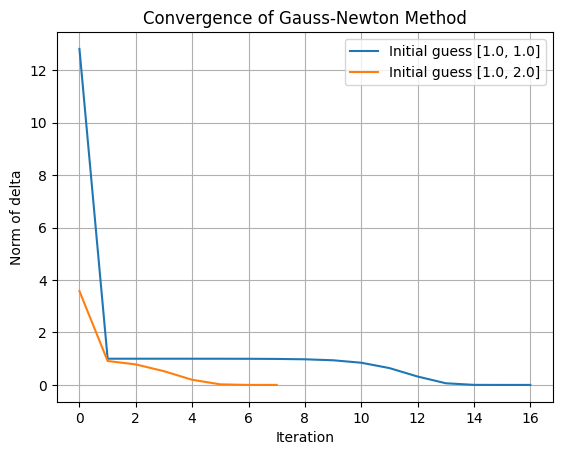

In [ ]:
# Problem 1c 
# Test with Newton's method
def newtons_method_2d( f, Jf, theta0, tol=1e-6, max_iter=1000 ):
    theta = theta0
    history = []
    for i in range(max_iter):
        F_val = f(theta)
        Jf_val = Jf(theta)
        
        # Solve Jf * delta = -F for delta
        try:
            delta = np.linalg.solve(Jf_val, -F_val)
        except np.linalg.LinAlgError:
            print("Jacobian is singular. Stopping iteration.")
            break
        
        theta += delta
        history.append(np.linalg.norm(delta))
        
        if np.linalg.norm(delta) < tol:
            print(f"Convergence achieved after {i+1} iterations.")
            return theta, history
    
    print("Maximum iterations reached without convergence.")
    return theta, history

theta0 = np.array([1.0, 1.0])
theta_opt, history1 = newtons_method_2d(
    lambda theta: F(theta, x, y), 
    lambda theta: jacobian_F(theta, x, y), 
    theta0
)
print("Optimal theta:", theta_opt)

theta0 = np.array([1.0, 2.0])
theta_opt, history2 = newtons_method_2d(
    lambda theta: F(theta, x, y), 
    lambda theta: jacobian_F(theta, x, y), 
    theta0
)
print("Optimal theta for initial guess [1.0, 2.0]:", theta_opt)

# graph the history of theta values for both initial guesses
import matplotlib.pyplot as plt

plt.plot(history1, label='Initial guess [1.0, 1.0]')
plt.plot(history2, label='Initial guess [1.0, 2.0]')
plt.xlabel('Iteration')
plt.ylabel('Norm of delta')
plt.title('Convergence of Gauss-Newton Method')
plt.grid()
plt.legend()
plt.show()

Convergence achieved after 4 iterations.
Optimal theta (Gauss-Newton) for initial guess [1.0, 1.0]: [ 1.1        -1.60297928]
Convergence achieved after 4 iterations.
Optimal theta (Gauss-Newton) for initial guess [1.0, 2.0]: [ 1.1        -1.60297928]


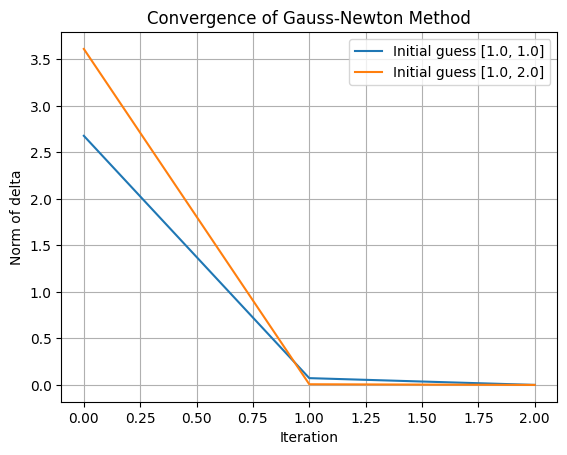

In [67]:
# Problem 1d 
# use Gauss Newton method

def gauss_newton_method( f, Jf, theta0, tol=1e-6, max_iter=1000 ):
    theta = theta0
    history = []
    for i in range(max_iter):
        F_val = f(theta)
        Jf_val = Jf(theta)
        
        # Solve Jf^T * Jf * delta = -Jf^T * F for delta
        try:
            A = Jf_val.T @ Jf_val
            b = -Jf_val.T @ F_val
            delta = np.linalg.solve(A, b)
        except np.linalg.LinAlgError:
            print("Normal equations are singular. Stopping iteration.")
            break
        
        theta += delta
        
        if np.linalg.norm(delta) < tol:
            print(f"Convergence achieved after {i+1} iterations.")
            return theta, history
        history.append(np.linalg.norm(delta))
    
    print("Maximum iterations reached without convergence.")
    return theta, history

theta0 = np.array([1.0, 1.0])
xData = np.array([
    i/19 for i in range(20)
])

yData = np.array([
    phi(xi, np.array([1.0, 2.0])) + 0.1 * (-1)**i for i, xi in enumerate(xData)
])

theta_opt, history1 = gauss_newton_method(
    lambda theta: F(theta, xData, yData), 
    lambda theta: jacobian_F(theta, xData, yData), 
    theta0
)
print("Optimal theta (Gauss-Newton) for initial guess [1.0, 1.0]:", theta_opt)

theta0 = np.array([1.0, 2.0])
theta_opt, history2 = gauss_newton_method(
    lambda theta: F(theta, xData, yData), 
    lambda theta: jacobian_F(theta, xData, yData), 
    theta0
)
print("Optimal theta (Gauss-Newton) for initial guess [1.0, 2.0]:", theta_opt)

# print history
import matplotlib.pyplot as plt
plt.plot(history1, label='Initial guess [1.0, 1.0]')
plt.plot(history2, label='Initial guess [1.0, 2.0]')
plt.xlabel('Iteration')
plt.ylabel('Norm of delta')
plt.title('Convergence of Gauss-Newton Method')
plt.grid()
plt.legend()
plt.show()

Convergence achieved after 14020 iterations.
Optimal theta from steepest descent: [1.00680312 1.98990425]
Convergence achieved after 8773 iterations.
Optimal theta from steepest descent with initial guess [1.0, 2.0]: [1.00678691 1.98992405]


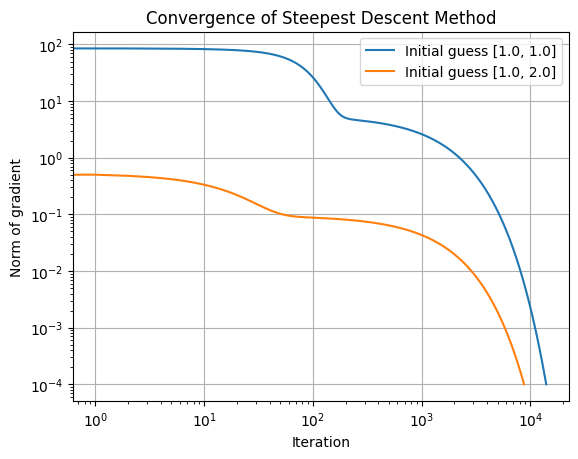

In [68]:
# Problem 1e
# Test with nonlinear least squares--steepest descent with etc = 1e-4
def steepest_descent( f, grad_f, theta0, stepsize=1e-4, tol=1e-4, max_iter=100000 ):
    theta = theta0
    history = []
    for i in range(max_iter):
        grad = grad_f(theta)
        if np.linalg.norm(grad) < tol:
            print(f"Convergence achieved after {i+1} iterations.")
            return theta, history
        
        # Update theta in the direction of the negative gradient
        theta -= stepsize * grad  # Step size can be adjusted
        history.append(np.linalg.norm(grad))

        
    print("Maximum iterations reached without convergence.")
    return theta, history


# g(theta) = 1/2 ||F(theta)||^2
# \nabla g(theta) = J_F(theta)^T F(theta)
# theta_{k+1} = theta_k - eta * \nabla g(theta_k)
def g(theta, x, y):
    return 0.5 * np.sum((phi(x, theta) - y)**2)

def gradient_g(theta, x, y):
    residuals = phi(x, theta) - y
    grad = np.zeros_like(theta)
    for i in range(len(x)):
        grad[0] += residuals[i] * np.exp(theta[1] * x[i])
        grad[1] += residuals[i] * theta[0] * x[i] * np.exp(theta[1] * x[i])
    return grad

theta0 = np.array([1.0, 1.0])
theta_opt_sd, history_sd_1 = steepest_descent(
    lambda theta: g(theta, xData, yData), 
    lambda theta: gradient_g(theta, xData, yData),
    theta0
)
print("Optimal theta from steepest descent:", theta_opt_sd)

theta0 = np.array([1.0, 2.0])
theta_opt_sd, history_sd_2 = steepest_descent(
    lambda theta: g(theta, xData, yData), 
    lambda theta: gradient_g(theta, xData, yData),
    theta0
)
print("Optimal theta from steepest descent with initial guess [1.0, 2.0]:", theta_opt_sd)

# graph the history of theta values for both initial guesses
plt.plot(history_sd_1, label='Initial guess [1.0, 1.0]')
plt.plot(history_sd_2, label='Initial guess [1.0, 2.0]')
plt.loglog()  # Use logarithmic scale for better visibility of convergence
plt.xlabel('Iteration')
plt.ylabel('Norm of gradient')
plt.title('Convergence of Steepest Descent Method')
plt.grid()
plt.legend()
plt.show()

In [69]:
# 1f use scipy.optimize.curve_fit

from scipy.optimize import curve_fit
def model(x, a, b):
    return a * np.exp(b * x)

# supress covariance of parameters could not be estimated warning
import warnings, scipy
warnings.filterwarnings("ignore", category=scipy.optimize.OptimizeWarning)


popt, pcov = curve_fit(model, xData, yData, p0=[1.0, 1.0])
print("Optimal parameters from curve_fit:", popt)

Optimal parameters from curve_fit: [1.00679501 1.98991415]


The two models agree to a good degree!

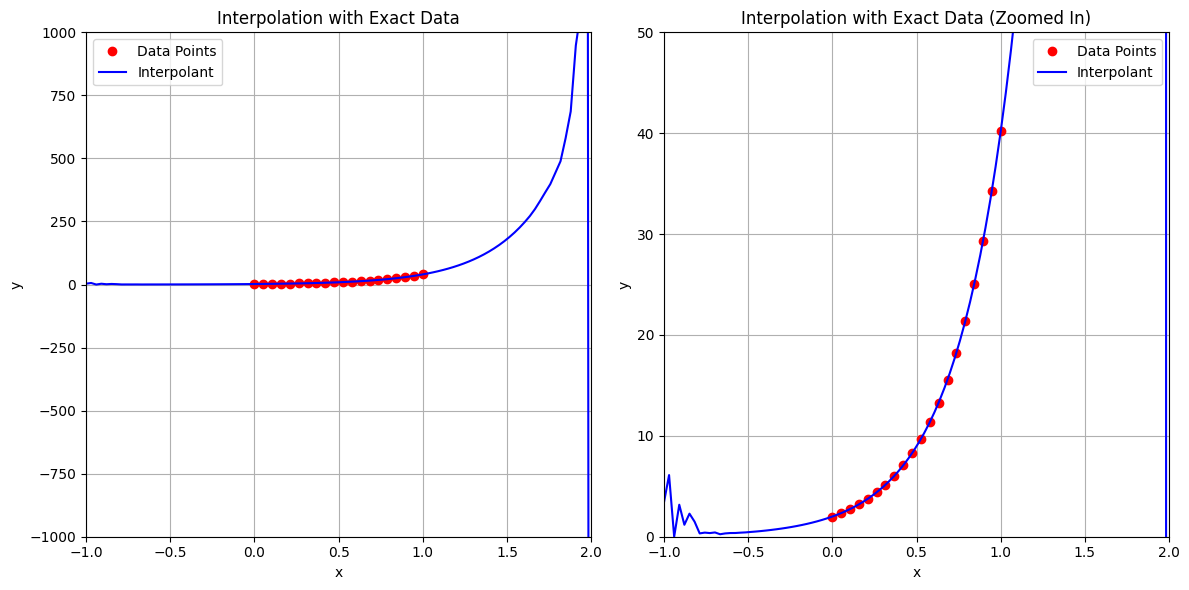

In [ ]:
# Problem 2a

from scipy.interpolate import BarycentricInterpolator
# For theta_star = [2,3], set yi = phi_theta_star (xi) for i = 1, 2, ..., 20, and interpolate data. Plot the data points, interpolant, 
# with x axis between [-1,2]. Create two plots, one with a y-axis showing [-1000, 1000] and another with a y-axis zoomed in to [0, 50].
xData = np.array([
    i/19 for i in range(20)
])

theta_star = np.array([2.0, 3.0])
yData_exact = phi(xData, theta_star)
interpolator_exact = BarycentricInterpolator(xData, yData_exact)

x_plot = np.linspace(-1, 2, 100)
y_plot_exact = interpolator_exact(x_plot)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(xData, yData_exact, 'ro', label='Data Points')
plt.plot(x_plot, y_plot_exact, 'b-', label='Interpolant')
plt.xlim(-1, 2)
plt.ylim(-1000, 1000)
plt.title('Interpolation with Exact Data')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(xData, yData_exact, 'ro', label='Data Points')
plt.plot(x_plot, y_plot_exact, 'b-', label='Interpolant')
plt.xlim(-1, 2)
plt.ylim(0, 50)
plt.title('Interpolation with Exact Data (Zoomed In)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

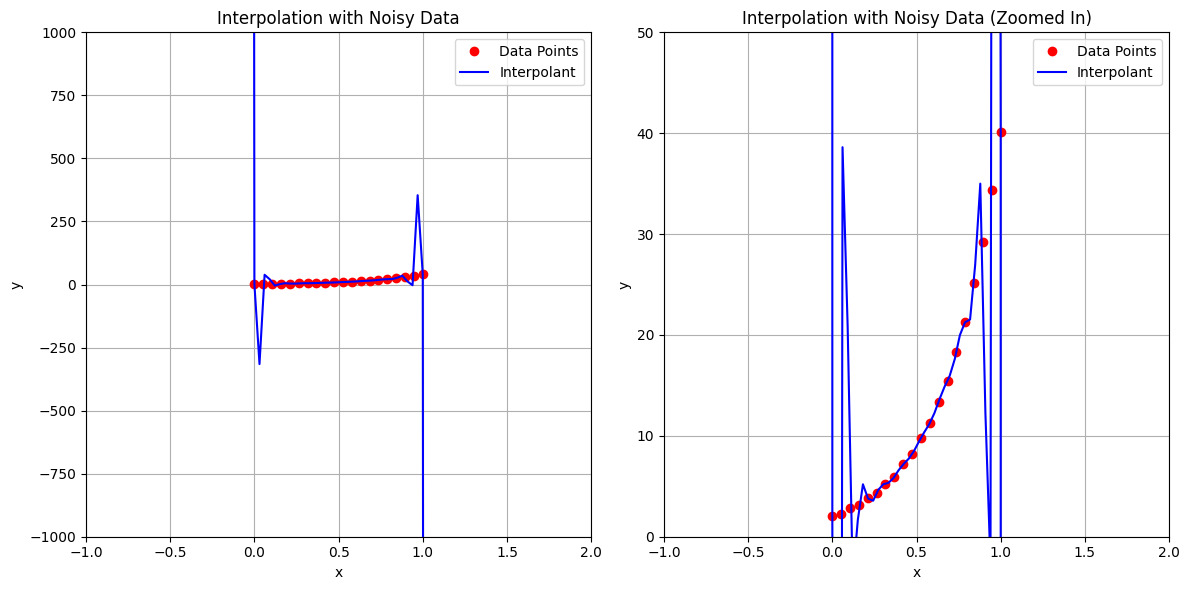

In [72]:
# Repeat the above with yi = phi_theta_star (xi) + 0.1 * (-1)**i for i = 1, 2, ..., 20, and plot the data points, interpolant, 
# with x axis between [-1,2]. Create two plots, one with a y-axis showing [-1000, 1000] and another with a y-axis zoomed in to [0, 50].
yData_noisy = yData_exact + 0.1 * np.array([(-1)**i for i in range(20)])
interpolator_noisy = BarycentricInterpolator(xData, yData_noisy)

y_plot_noisy = interpolator_noisy(x_plot)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(xData, yData_noisy, 'ro', label='Data Points')
plt.plot(x_plot, y_plot_noisy, 'b-', label='Interpolant')
plt.xlim(-1, 2)
plt.ylim(-1000, 1000)
plt.title('Interpolation with Noisy Data')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(xData, yData_noisy, 'ro', label='Data Points')
plt.plot(x_plot, y_plot_noisy, 'b-', label='Interpolant')
plt.xlim(-1, 2)
plt.ylim(0, 50)
plt.title('Interpolation with Noisy Data (Zoomed In)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Part c: Comment on what you've observed
When we add in the noise to the data, however slight, the interpolant fits the data, but is horribly innacruate for any data outside. This can be attributed to the Runge phenomenon, most clearly seen at the endpoints of the noisy data. Here, since the polynomial degree is high, the function looses predictive accuracy. This is similar to the Gibbs phenomenon in the Fourier Methods class I took last semester.

## Problem 3: Is the Barycentric formula ill-conditioned?
### Part a
Consider $f(x) = \frac{1}{1-x}$
- Find the relative condition number of evaluting $f$. Is this good or bad when $x\approx 1$?
    - $$\kappa_f(x) = \left| \frac{xf'(x)}{f(x)} \right| = \left| \frac{x\frac{1}{(1-x)^2} }{\frac{1}{1-x}} \right| = \left| \frac{x(1-x)}{(1-x)^2} \right| = \left| \frac{x}{1-x} \right|.$$
    When $x\approx 1$, this approaches infinity! This problem is very ill conditioned and we should loose an arbitrary number of bits close to 1.
- Actually evaluate $f$ for $x=1-10^{-13}$ on the cmoputer, using any software.

In [88]:
# Evaluate 1/(1-x) for x=1-10^{-13} with floating point numbers
x = float(1 - 10**(-13))
result = 1 / (1 - x)

trueResult = 1e13

print("Result of 1/(1-x) for x=1-10^{-13}:", result)
print("Digits lost: ", -np.log10(abs(result - trueResult)/abs(trueResult)))

Result of 1/(1-x) for x=1-10^{-13}: 9996891514695.885
Digits lost:  3.5074511814908544


- About how many correct digits do you have? Is this expected?
    - Plug in $1-10^{-13}$ to $\kappa_f (x)$: $$\kappa_f (1-10^{-13}) = \left| \frac{1-10^{-13}}{10^{-13}} \right| \approx 10^{13}.$$ In double precision, we have $\epsilon_{m}\approx 10^{-16}$, so the relative error in $f(x)$ should be about $10^{13}\cdot 10^{-16} = 10^{-3},$ exactly how many digits were lost. 
- If you evaluate $f$ for $x=1-2^{-43} \approx 1-1.13\cdot 10^{-13}$, how many correct digits do you have now?

In [ ]:
# If you evaluate $f$ for $x=1-2^{-43} \approx 1-1.13\cdot 10^{-13}$, how many correct digits do you have now?
x1 = float(1 - 2**(-43))
result1 = 1 / (1 - x1)

x2 = float(1- 1.13e-13)
result2 = 1 / (1 - x2)

trueResult = 2**43

print("Result of 1/(1-x) for x=1-2^{-43}:", result1)
print("Digits lost: ", -np.log10(abs(result1 - trueResult)/abs(trueResult)))

print("Result of 1/(1-x) for x=1-1.13e-13:", result2)
print("Digits lost: ", -np.log10(abs(result2 - trueResult)/abs(trueResult)))

Result of 1/(1-x) for x=1-2^{-43}: 8796093022208.0
Digits lost:  inf
Result of 1/(1-x) for x=1-1.13e-13: 8847936399549.107
Digits lost:  2.2295965276171015


We most no digits of accuracy when $x=1-2^{-43}$ becuase this number is exactly representable in IEEE double precision! So the subtraction was exact. However, when we switched to the $x=1-1.13\times 10^{-13}$ form, this number is not exactly representable, and the subtraction introduced catastrophic cancellation. 

## Part b
The barycentric formula for Lagrange interpolation looks like $$p(x) = \sum_{i=0}^n \frac{\frac{w_i}{x-x_i}y_i}{\frac{w_i}{x-x_i}}$$ which might make you nervous when $x\approx x_i$ for some $i$. Let's analyze $$f(x) = \frac{\frac{c}{1-x}+d}{\frac{1}{1-x} + a}$$ for some constant $a$, $d$, and some $c\ne 0$.
- Find $\lim_{x\to 1}f(x)$
    - Notice that $$f(x) = \frac{c+d(1-x)}{1+a(1-x)},$$ so $$\lim_{x\to 1} = c$$
- Find the relative condition number $\kappa_f$ for $x=1$
    - Compute $$f'(x) = \frac{-d \cdot (1+a(1-x)) - (-a)(c+d(1-x))}{(1+a(1-x))^2}$$ so that $$f'(1) = ac-d$$ then $$f(1) = c,$$ so $$\kappa_f(1) = \left| \frac{1\cdot(ac-d)}{c} \right| $$